# Ecommence Spend Prediction - XGBoost 

In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import optuna
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import shap

In [2]:
client = bigquery.Client(project="first-project-321219")

query = """
WITH session_windows AS (
    -- Step 1: Define the start and end of every session
    SELECT
        session_id,
        user_id,
        MIN(created_at) AS session_start,
        MAX(created_at) AS session_end
    FROM `bigquery-public-data.thelook_ecommerce.events`
    WHERE created_at >= '2022-01-01'
    GROUP BY 1, 2
),
order_totals AS (
    -- Step 2: Get total value for every order
    SELECT
        user_id,
        order_id,
        created_at,
        SUM(sale_price) AS total_value
    FROM `bigquery-public-data.thelook_ecommerce.order_items`
    GROUP BY 1, 2, 3
)

SELECT
    sw.session_id,
    sw.user_id,
    u.age,
    u.gender,
    u.country,
    u.traffic_source,
    sw.session_start,

    -- FEATURE: Total spend BEFORE this session started
    COALESCE((
        SELECT SUM(ot.total_value)
        FROM order_totals ot
        WHERE ot.user_id = sw.user_id
          AND ot.created_at < sw.session_start
    ), 0) AS past_total_spend_before_session,

    -- FEATURE: Session count prior to this one
    COUNT(*) OVER (
        PARTITION BY sw.user_id
        ORDER BY sw.session_start
        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
    ) AS number_of_prior_session_count,

    -- TARGET: Total spend WITHIN this session
    -- We look for orders by this user that happened between the session start and end
    COALESCE((
        SELECT SUM(ot.total_value)
        FROM order_totals ot
        WHERE ot.user_id = sw.user_id
          AND ot.created_at BETWEEN sw.session_start AND sw.session_end
    ), 0) AS label_session_spend

FROM session_windows sw
JOIN `bigquery-public-data.thelook_ecommerce.users` u ON sw.user_id = u.id
ORDER BY sw.user_id, sw.session_start
"""

df = client.query(query).to_dataframe()
print(df.head())

                             session_id  user_id  age gender country  \
0  abe87607-73c1-4375-9dc6-65d8bcaff156        2   39      M   China   
1  23a75523-c1d5-44ea-bff7-7e464ab64b68        3   30      M   China   
2  194cd385-b1f7-469a-a2cf-b785dc6d4536        3   30      M   China   
3  366031ab-19d0-4863-85fe-21c0eb58a3f5        3   30      M   China   
4  0182195c-4c71-4f76-a76d-c77b233a9def        3   30      M   China   

  traffic_source             session_start  past_total_spend_before_session  \
0         Search 2022-02-03 14:28:47+00:00                          0.00000   
1        Organic 2026-03-04 07:29:19+00:00                        349.48999   
2        Organic 2026-03-04 07:39:18+00:00                        349.48999   
3        Organic 2026-03-04 08:41:46+00:00                        349.48999   
4        Organic 2026-03-04 09:58:41+00:00                        379.47999   

   number_of_prior_session_count  label_session_spend  
0                              0    

## Load Data

In [3]:
def load_data(dataframe, datefrom=None, dateto=None):
    if not isinstance(
        dataframe, pd.DataFrame
    ):  # isinstance(): check specified object is in specificed type.
        print("Error: Input is not a DataFrame")
        return None

    if "label_session_spend" not in dataframe.columns:
        print("Column Error: label_total_spend is not in DataFrame")
        return dataframe

    try:
        dataframe["session_start"] = pd.to_datetime(dataframe["session_start"])
    except Exception:
        print(f"Date Conversion Error: {Exception}")

    return dataframe

In [4]:
df_raw = load_data(df)
df_raw.head()

,session_id,user_id,age,gender,country,traffic_source,session_start,past_total_spend_before_session,number_of_prior_session_count,label_session_spend
0,abe87607-73c1-4375-9dc6-65d8bcaff156,2,39,M,China,Search,2022-02-03 14:28:47+00:00,0.00000,0,0.000000
1,23a75523-c1d5-44ea-bff7-7e464ab64b68,3,30,M,China,Organic,2026-03-04 07:29:19+00:00,349.48999,0,156.240000
2,194cd385-b1f7-469a-a2cf-b785dc6d4536,3,30,M,China,Organic,2026-03-04 07:39:18+00:00,349.48999,1,62.749998
3,366031ab-19d0-4863-85fe-21c0eb58a3f5,3,30,M,China,Organic,2026-03-04 08:41:46+00:00,349.48999,2,29.990000
4,0182195c-4c71-4f76-a76d-c77b233a9def,3,30,M,China,Organic,2026-03-04 09:58:41+00:00,379.47999,3,76.259998


## EDA & Data Cleaning

In [5]:
df_raw.isnull().sum()

session_id                         0
user_id                            0
age                                0
gender                             0
country                            0
traffic_source                     0
session_start                      0
past_total_spend_before_session    0
number_of_prior_session_count      0
label_session_spend                0
dtype: int64

In [6]:
df_raw.info()
# We will use age, gender, country, traffic_source, session_start, past_total_spend_before_session, number_of_prior_session_coun as features

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163336 entries, 0 to 163335
Data columns (total 10 columns):
 #   Column                           Non-Null Count   Dtype              
---  ------                           --------------   -----              
 0   session_id                       163336 non-null  object             
 1   user_id                          163336 non-null  Int64              
 2   age                              163336 non-null  Int64              
 3   gender                           163336 non-null  object             
 4   country                          163336 non-null  object             
 5   traffic_source                   163336 non-null  object             
 6   session_start                    163336 non-null  datetime64[us, UTC]
 7   past_total_spend_before_session  163336 non-null  float64            
 8   number_of_prior_session_count    163336 non-null  Int64              
 9   label_session_spend              163336 non-null  float64  

In [7]:
df_raw.describe()

,user_id,age,past_total_spend_before_session,number_of_prior_session_count,label_session_spend
count,163336.0,163336.0,163336.000000,163336.0,163336.000000
mean,49852.178197,41.006784,52.816974,1.148222,53.713056
std,28836.719268,16.974671,102.736043,1.474871,89.014731
min,2.0,12.0,0.000000,0.0,0.000000
25%,24903.75,26.0,0.000000,0.0,0.000000
50%,49819.5,41.0,0.000000,1.0,12.990000
75%,74824.25,56.0,64.940001,2.0,76.000000
max,100000.0,70.0,1587.449997,12.0,1465.980000


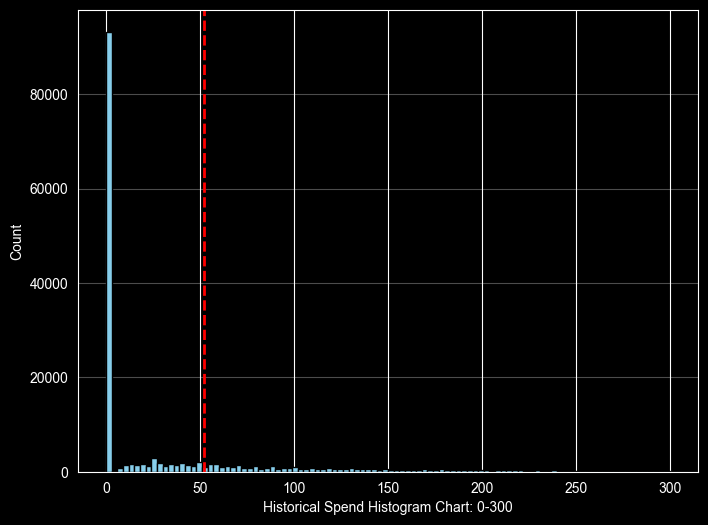

In [8]:
# past_total_spend_before_session mean is 52 but the max is 1530. Plotting a histogram chart to understand the distribution
plt.figure(figsize=(8, 6))
plt.hist(
    x=df_raw["past_total_spend_before_session"],
    bins=100,
    range=(0, 300),
    color="skyblue",
    edgecolor="black",
)

plt.axvline(52, color="red", linestyle="dashed", linewidth=2, label="Mean Spend: 52")
plt.xlabel("Historical Spend Histogram Chart: 0-300")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [9]:
df_raw[df_raw["past_total_spend_before_session"] == 0]["past_total_spend_before_session"].count()
# 57% of records are 0 spend. It caused right-skewed distribution

93223

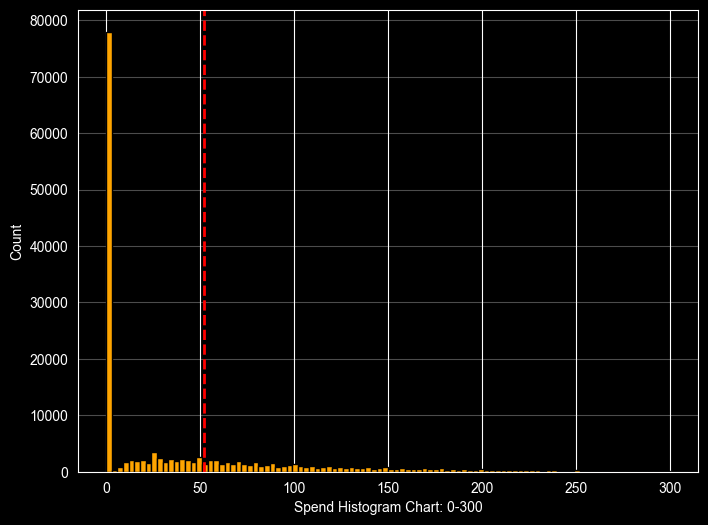

In [10]:
plt.figure(figsize=(8, 6))
plt.hist(
    x=df_raw["label_session_spend"], bins=100, range=(0, 300), color="orange", edgecolor="black"
)

plt.axvline(52, color="red", linestyle="dashed", linewidth=2, label="Mean Spend: 52")
plt.xlabel("Spend Histogram Chart: 0-300")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [11]:
df_raw[df_raw["label_session_spend"] == 0]["label_session_spend"].count()
# 48% of records are 0 spend. It caused right-skewed distribution. We will use log transformation to reduce the normalise skewed data distribution

77929

## Data Processing

In [12]:
def prepare_data(df_input, target="label_session_spend"):
    # Feature Engineering
    df_input["day_num"] = df_input["session_start"].dt.weekday
    df_input["is_weekend"] = (df_input["day_num"] >= 5).astype(int)
    df_input["hour"] = df_input["session_start"].dt.hour

    df_input["country"] = df_input["country"].replace(
        {"España": "Spain", "Deutschland": "Germany"}, regex=False
    )

    df_input["avg_spend_per_session"] = np.where(
        df_input["number_of_prior_session_count"] > 0,
        df_input["past_total_spend_before_session"] / df_input["number_of_prior_session_count"],
        0,
    )
    df_input["has_past_spend"] = (df_input["past_total_spend_before_session"] > 0).astype(int)

    # gamma:add 0.000001 to replace 0 value in label_session_spend. it will be used at gamma regression later
    # df_input['label_session_spend'] = np.where(df_input['label_session_spend'] == 0, 0.000001,df_input['label_session_spend'])

    df_proc = df_input.copy()
    df_proc = df_proc.drop(
        [
            "session_id",
            "user_id",
            "session_start",
            "day_num",
            "number_of_prior_session_count",
            "past_total_spend_before_session",
        ],
        axis=1,
    )

    # reg:gamma - filter label_session_spend >0. otherwise, it will return "label must be positive for gamma regression"
    # df_proc = df_proc[df_proc['label_session_spend'] > 0]

    return df_proc

In [13]:
df_prepare = prepare_data(df_raw)
df_prepare

,age,gender,country,traffic_source,label_session_spend,is_weekend,hour,avg_spend_per_session,has_past_spend
0,39,M,China,Search,0.000000,0,14,0.000000,0
1,30,M,China,Organic,156.240000,0,7,0.000000,1
2,30,M,China,Organic,62.749998,0,7,349.489990,1
3,30,M,China,Organic,29.990000,0,8,174.744995,1
4,30,M,China,Organic,76.259998,0,9,126.493330,1
...,...,...,...,...,...,...,...,...,...
163331,34,F,China,Search,0.000000,0,23,0.000000,0
163332,34,F,China,Search,35.860000,1,12,25.770000,1
163333,34,F,China,Search,13.870000,1,14,12.885000,1
163334,23,F,Germany,Organic,20.990000,0,20,0.000000,0


In [14]:
dataframe = df_prepare.copy()

num_cols = dataframe.select_dtypes(include=np.number)
num_cols_df = pd.DataFrame(num_cols)
matrix = num_cols_df.corr().astype(float)

fig = px.imshow(matrix, text_auto=".3f", aspect="auto", color_continuous_scale="RdBu_r")
fig.show()

# using seaborn, matplotlib won't show the figure in heatmap. therefore, i changed using plotly
# plt.figure(figsize = [8,6])
# sns.heatmap(matrix, annot=True, cmap = 'coolwarm', fmt='.3f',
#             annot_kws={'size': 10, 'color':'black'}
#              ,vmin=-1,vmax=1)
# plt.title('Correlation Heatmap')
# plt.tight_layout()
#
# plt.show()
# number_of_prior_session_count & past_total_spend_before_session is 0.644. i create an average spend per session column as feature engineering.
# only avg_spend_per_session & has_past_spend have medium level correlation. It might be because Pearson Correlation can only capture linear relationship

In [15]:
print(num_cols_df.nunique())

print(num_cols_df.isnull().sum())

age                         59
label_session_spend      26074
is_weekend                   2
hour                        24
avg_spend_per_session    30531
has_past_spend               2
dtype: int64
age                      0
label_session_spend      0
is_weekend               0
hour                     0
avg_spend_per_session    0
has_past_spend           0
dtype: int64


In [16]:
matrix = num_cols_df.corr(numeric_only=True)

In [17]:
# pip install --user xgboost

## Modelling

In [19]:
def prepare_var(df, target="label_session_spend", test_size=0.2, random_state=16):
    y = df[target]
    X = df.drop([target], axis=1)

    cat_col = X.select_dtypes(exclude=np.number).columns.tolist()

    for col in cat_col:
        X[col] = X[col].astype("category")

    # Split to Train, Val
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # split X_train_val, y_train_val for Optuna
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=test_size, random_state=random_state
    )

    return X_train, y_train, X_val, y_val, X_test, y_test

In [20]:
def optimise_xgboost(X_train, y_train, X_val, y_val):
    def objective(trial):
        param = {
            "n_estimators": 1000,  # total number fo trees. if there's too many trees, it can cause overfitting
            "max_depth": trial.suggest_int(
                "max_depth", 4, 8
            ),  # the max depth(how many layers) for each trees. model can learn more complex rules for purchase/not purchase. e.g. age <25, is_weekend = No is not purchase..
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.01, 0.1, log=True
            ),  # the speed of learning, the current tree corrects previous tree mistake
            "objective": "reg:tweedie",
            "tree_method": "hist",  # Histogram Algorithm: faster way to calculate
            "enable_categorical": True,
            "device": "cpu",
            "n_jobs": -1,
            "eval_metric": "mae",
            "early_stopping_rounds": 50,
        }

        reg = xgb.XGBRegressor(**param)

        # reg.fit(X_train, y_train)

        reg.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        preds = reg.predict(X_val)
        mae = mean_absolute_error(y_val, preds)
        return mae

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=50, show_progress_bar=True)
    return study.best_params
    # print the best hyperparameters
    # print('Best hyperparameters: ', study.best_params)
    # print('Best performance: ', study.best_value)

In [21]:
def xgboost(X_train, y_train, X_test, y_test, best_params, test_size=0.2, random_state=16):
    # 2) use the best params to train the model

    model = xgb.XGBRegressor(
        **best_params,
        tree_method="hist",
        enable_categorical=True,
        objective="reg:tweedie",
        tweedie_variance_power=1.7,
    )
    # gamma regression
    # model = xgb.XGBRegressor(**best_params, tree_method='hist', enable_categorical=True, objective = 'reg:gamma')

    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    # predict
    preds = model.predict(X_test)

    # evaluate performance
    mse = mean_squared_error(y_test, preds)
    rmse = mse**0.5
    mae = mean_absolute_error(y_test, preds)
    # r2 = r2_score(y_test, preds)
    print(f"RMSE is: {rmse:.3f}")
    # print(f'R_squared: {r2:.3f}')
    print(f"Mean Absolute Error: {mae:.3f}")

    # return the feature's importance

    importance = pd.DataFrame(
        {"feature": X_train.columns, "importance": model.feature_importances_}
    ).sort_values(by="importance", ascending=False)

    plt.scatter(y_test, preds)
    plt.show()

    return model, y_test, preds, importance

In [22]:
# split data training, validation, test set
X_train, y_train, X_val, y_val, X_test, y_test = prepare_var(df_prepare)

In [23]:
# find best params
# best_param = optimise_xgboost(X_train, y_train, X_val, y_val)

RMSE is: 91.580
Mean Absolute Error: 56.471


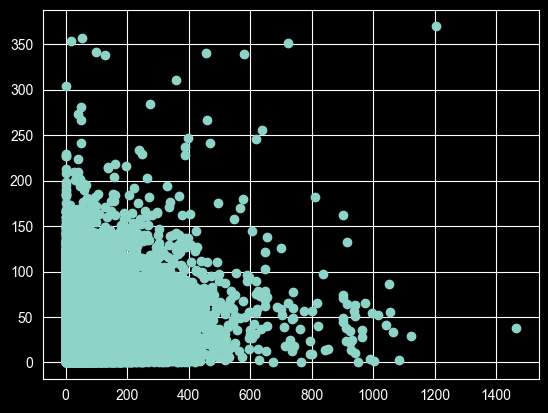

In [24]:
best_param = {"max_depth": 8, "learning_rate": 0.09787127008675124, "n_estimators": 1000}
final_model, y_test, preds, importance = xgboost(X_train, y_train, X_test, y_test, best_param)

15/02/2026:
reg: gamma
Best Params: {'subsample': 0.9, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
RMSE is: 102.376
Mean Absolute Error: 68.905

reg:tweedie
Best Params: {'subsample': 0.9, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
RMSE is: 87.682
Mean Absolute Error: 58.329

using tweedie has smaller RMSE and MAE. Also, tweedie can deal with 0 data

21/02/2026
#### Model Selection: Tweedie Variance Power Tuning
In this e-commerce dataset, the average spend is 52, with a high frequency of zero values (non-buyers). 

- **MAE vs. RMSE**: I prioritized **MAE (Mean Absolute Error)** as it reflects the average deviation for the majority of customers. While **RMSE** is sensitive to large errors, in our case, those large errors usually stem from a small number of "whale" customers (high spenders).
- **Optimization**: Increasing the `tweedie_variance_power` towards 1.7 significantly improved the MAE, meaning the model became more accurate for the typical customer.
- **Decision**: I selected **tweedie_variance_power = 1.7** as it achieved the lowest MAE (56.266) while keeping the RMSE stable, providing the best balance for predicting general consumer behavior.
RMSE is: 89.758
Mean Absolute Error: 58.238

tweedie_variance_power = 1.2
RMSE: 89.620
Mean Absolute Error : 57.841

tweedie_variance_power = 1.5
RMSE is: 89.722
Mean Absolute Error: 56.693


tweedie_variance_power = 1.7
RMSE is: 90.262
Mean Absolute Error: 56.266

tweedie_variance_power = 1.9
RMSE is: 91.326
Mean Absolute Error: 56.390

using Gamma regression:
RMSE is: 91.160
Mean Absolute Error: 56.815

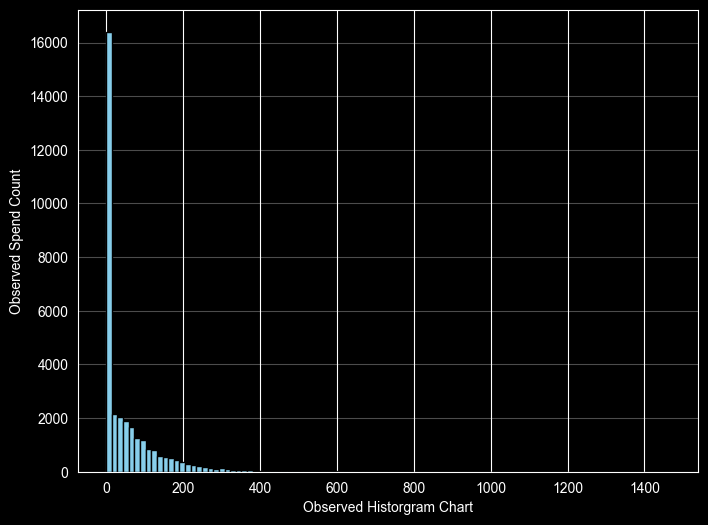

In [25]:
plt.figure(figsize=(8, 6))
plt.hist(x=y_test, bins=100, color="skyblue", edgecolor="black")
plt.xlabel("Observed Historgram Chart")
plt.ylabel("Observed Spend Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

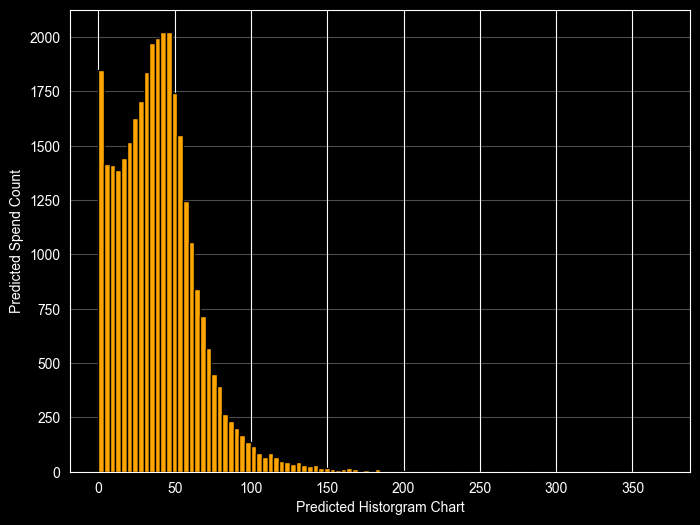

In [26]:
plt.figure(figsize=(8, 6))
plt.hist(x=preds, bins=100, color="orange", edgecolor="black")
plt.xlabel("Predicted Historgram Chart")
plt.ylabel("Predicted Spend Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

The predicted value (preds) represents an expected value. For example, if the true label (y_test) is 0, but the model predicts a 10% probability of a 100 spend and a 90% probability of a 0 spend, the resulting prediction is 10 (100 * 0.1 + 0 * 0.9 = 10). 
Consequently, many predicted values fall within the 0 to 80 range. 
Furthermore, regression models tend to target the central tendency to minimise metrics like MAE or RMSE, often leading to more conservative, lower spend estimates.

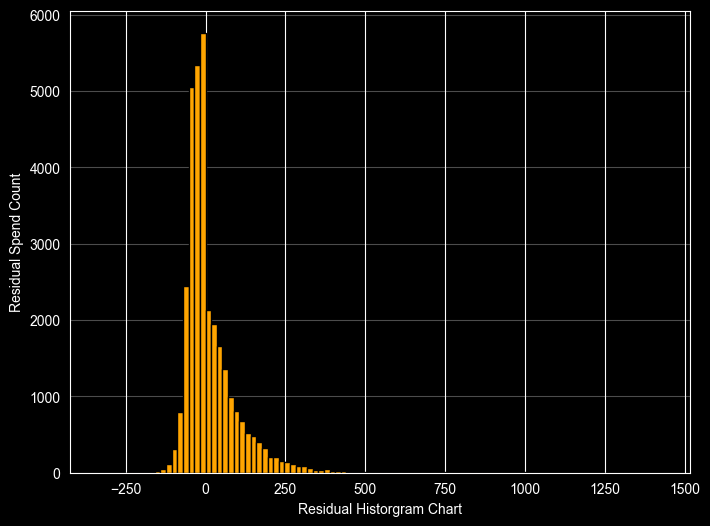

In [27]:
residual = y_test - preds

plt.figure(figsize=(8, 6))
plt.hist(x=residual, bins=100, color="orange", edgecolor="black")
plt.xlabel("Residual Historgram Chart")
plt.ylabel("Residual Spend Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

The residual histogram resembles a normal distribution. 
This indicates that most residuals are concentrated between -20 and 20, balancing the large volume of zero-spend instances. 
While there are small proportions of both overestimated and underestimated values, there is a slightly higher frequency of underestimation (visible on the right side of the chart). 
This suggests that the model tends to under-predict when actual spending is high.

In [28]:
result_test_preds = pd.DataFrame({"Actual_Spend": y_test.values, "Predicted_Spend": preds})

result_test_preds["Residual"] = (
    result_test_preds["Actual_Spend"] - result_test_preds["Predicted_Spend"]
)

# result_test_preds.to_excel('pred_test_residual.xlsx', index = False)
print("export successful")

export successful


In [29]:
result_test_preds["Residual"].mean()

15.014758659988992

In [30]:
importance

,feature,importance
7,has_past_spend,0.163667
2,country,0.139269
3,traffic_source,0.138651
5,hour,0.115199
4,is_weekend,0.115006
0,age,0.112004
6,avg_spend_per_session,0.110306
1,gender,0.105898


In [31]:
# pip install optuna

In [32]:
def SHAP_Importance(model, X_test):
    # Build Explainer: using TreeExplainer for XGBoost
    #  explainer = shap.Explainer(model)
    explainer = shap.TreeExplainer(model)

    # Calculate SHAP values
    # shap_values = explainer(X_test.iloc[:500, :])
    shap_values = explainer(X_test)

    # shap.initjs()

    # bar chart: which feature is more important?
    plt.figure()
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.title("Feature Importance (SHAP Bar)")
    plt.show()

    # scatter chart: how the features impact the prediction when feature is higher/lower
    plt.figure()
    shap.summary_plot(shap_values, X_test, show=False)
    plt.show()

    plt.figure()
    shap.plots.waterfall(shap_values[0], show=False)
    plt.show()

    if "country" in X_test.columns:
        plt.figure()
        shap.dependence_plot(
            "country", shap_values.values, X_test, interaction_index=None, show=False
        )
        plt.title("Impact of Country Labels")
        plt.show()

    return shap_values

In [33]:
# pip install tqdm

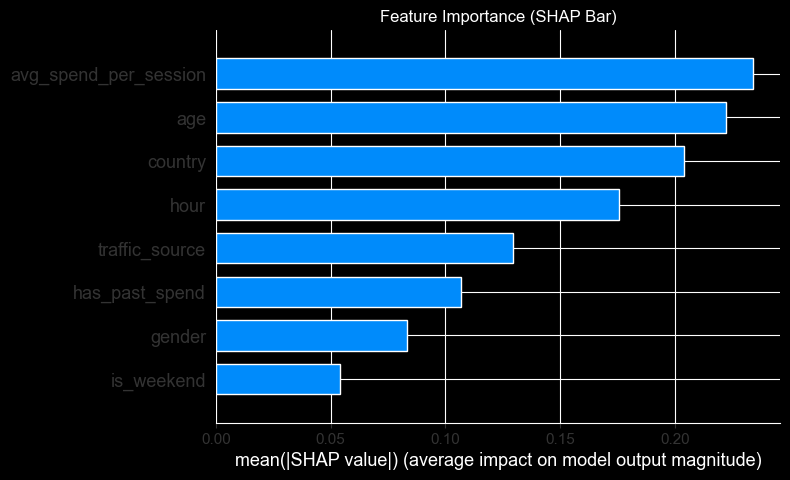

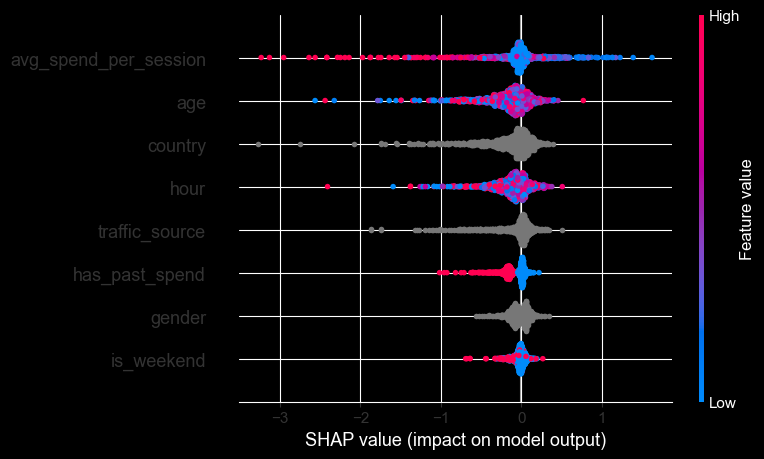

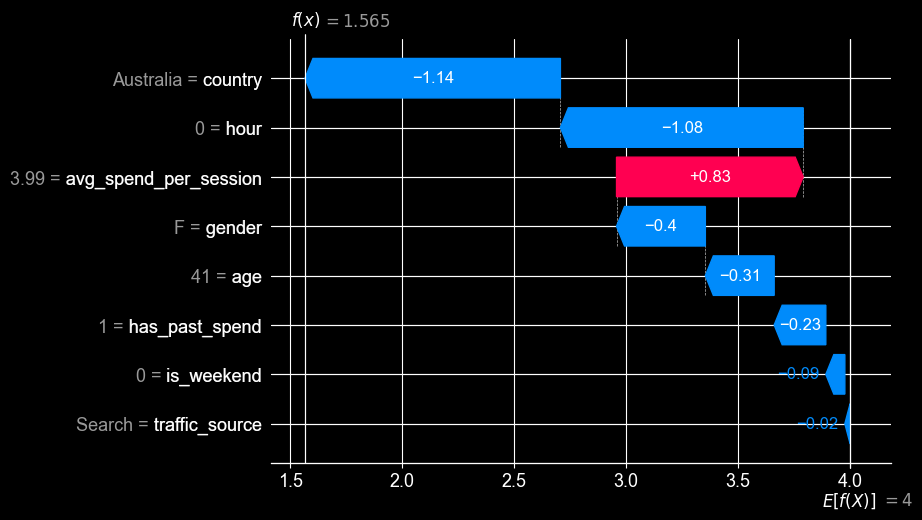

<Figure size 640x480 with 0 Axes>

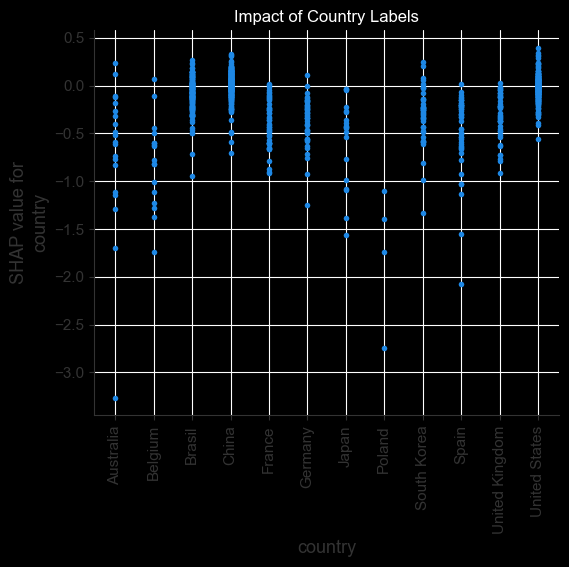

In [34]:
SHAP_Values = SHAP_Importance(final_model, X_test.iloc[:1000, :])

In [35]:
print(type(SHAP_Values))

<class 'shap._explanation.Explanation'>


1. RandomizedSearchCV ("Random Guessing")
Mechanism: Randomly selects a fixed number of parameter combinations (e.g., n_iter=10) from a predefined grid.

Limitation (Blind Search): It is "memoryless." Each trial is independent; the algorithm does not learn from previous results. If max_depth=7 performs well, the next trial might still waste time testing max_depth=3.

Efficiency: Lower efficiency as it may miss the optimal point between the discrete values in your grid.

2. Optuna ("Bayesian Optimization")
Mechanism: Uses an automated, logic-based approach (specifically the TPE algorithm) to predict which parameter combinations are most promising based on prior trials.

Key Advantages:

Iterative Learning: It narrows the search space toward high-performing regions (e.g., if a learning_rate of 0.15 works well, it focuses subsequent trials around that area).

Continuous Search Space: Unlike the fixed lists in Random Search, Optuna can explore precise floating-point values (e.g., 0.1521) for better fine-tuning.

Pruning: Automatically terminates poorly performing trials early to save computational time.

In [36]:
# pip install xgboost shap pandas scikit-learn matplotlib ipywidgets

In [37]:
# Feature Importance
# At XGBoost feature importance, has_past_spend, country,traffic_source have higher score.
# Using has_past_spend at the top of tree is the most effective factor to split groups and reduce predicted error.


# At SHAP, avg_spend_per_session, age have higher score.
# When they change one unit, it can impact the spend more. They are the key factors that impact the amount of spend.

In [38]:
# avg_spend_per_session: when spend increased, predicted purchase spend decreased? when people spend so much in the past, their next purchase tend to be smaller.

# has_past_spend: when they have past spend, they tend to spend less/ don't spend. imply new customers are more profitable?

# age, hour: it's not simple linear relationship. it's not older/younger customers tend to spend more. maybe only a specific age group, or a specific hour.

# # is_weekend: weekend can spend more or less. it's not a stable feature?

In [39]:
# at the waterfall chart, it indicates customer from Germany can reduce predicted spend -0.59 units.
# When the customer has past spend, the model reduce predicted spend 0.47 unit

# at the country chart, it shows the potential customers and lower spend customers.
# e.g. if they are Austrlian customers, there's higher likelihood they will spend less.
# if they are Chinese customers, some customers will spend more (with other factors influence) while some of them will spend less.

## Result
avg_spend_per_session is the most important factor that impact the spend amount. when people spend so much in the past, their next purchase tend to be smaller
as customers with historical spend tend to spend less, it implied that new customeres have more potential to spend more.
age and hour are medium importance level factors while it is not a linear relationship with predicted spend. it means a specific age/hour of spend are higher/lower than average
When customers are Brasil/China/United States, some of them tend to spend more.

Action:
New Customers are the potential groups to spend more. 
Increase budget to channels that bring new customers.
Reduce budget to channels, ad creative that bring low potential customers who are from Australia, Japan who have high amount of average spend.
